# 🌸 Task 1: Exploring and Visualizing the Iris Dataset

## Problem Statement
The **Iris dataset** is a classic benchmark in machine learning. It contains measurements of 150 iris flowers from 3 different species: *Setosa*, *Versicolor*, and *Virginica*. Each sample has 4 features: sepal length, sepal width, petal length, and petal width (all in cm).

## Goal
- Load and inspect the dataset
- Understand distributions and relationships between features
- Identify patterns and outliers through visualizations
- Build a foundation for classification model training

---

## Step 1: Import Libraries

In [1]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot aesthetics
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## Step 2: Load the Dataset
We load the Iris dataset directly via **seaborn** (no download needed in Colab).

In [2]:
# Load Iris dataset using seaborn's built-in datasets
df = sns.load_dataset('iris')

# Preview the first 5 rows
print('📋 First 5 rows of the dataset:')
df.head()

📋 First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
## Step 3: Dataset Inspection
Understand the shape, data types, and any missing values.

In [3]:
# --- Shape and Columns ---
print(f'📐 Shape (rows, columns): {df.shape}')
print(f'\n📌 Column Names:\n{df.columns.tolist()}')

# --- Data Types and Null Check ---
print('\n🔍 Dataset Info:')
df.info()

📐 Shape (rows, columns): (150, 5)

📌 Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# --- Missing Values Check ---
missing = df.isnull().sum()
print('❓ Missing Values per Column:')
print(missing)
print(f'\n✅ Total missing values: {missing.sum()} — Dataset is clean!')

❓ Missing Values per Column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

✅ Total missing values: 0 — Dataset is clean!


In [5]:
# --- Class Distribution ---
print('🌺 Species Distribution:')
print(df['species'].value_counts())
print('\n→ Dataset is perfectly balanced: 50 samples per species.')

🌺 Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

→ Dataset is perfectly balanced: 50 samples per species.


---
## Step 4: Descriptive Statistics
`.describe()` gives us count, mean, std, min, quartiles, and max for all numeric columns.

In [6]:
# Summary statistics for all numeric features
print('📊 Descriptive Statistics:')
df.describe().round(2)

📊 Descriptive Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [7]:
# Per-species mean — more informative than overall stats
print('📊 Per-Species Feature Means:')
df.groupby('species').mean().round(2)

📊 Per-Species Feature Means:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


---
## Step 5: Data Visualization

### 5.1 — Scatter Plot: Feature Relationships

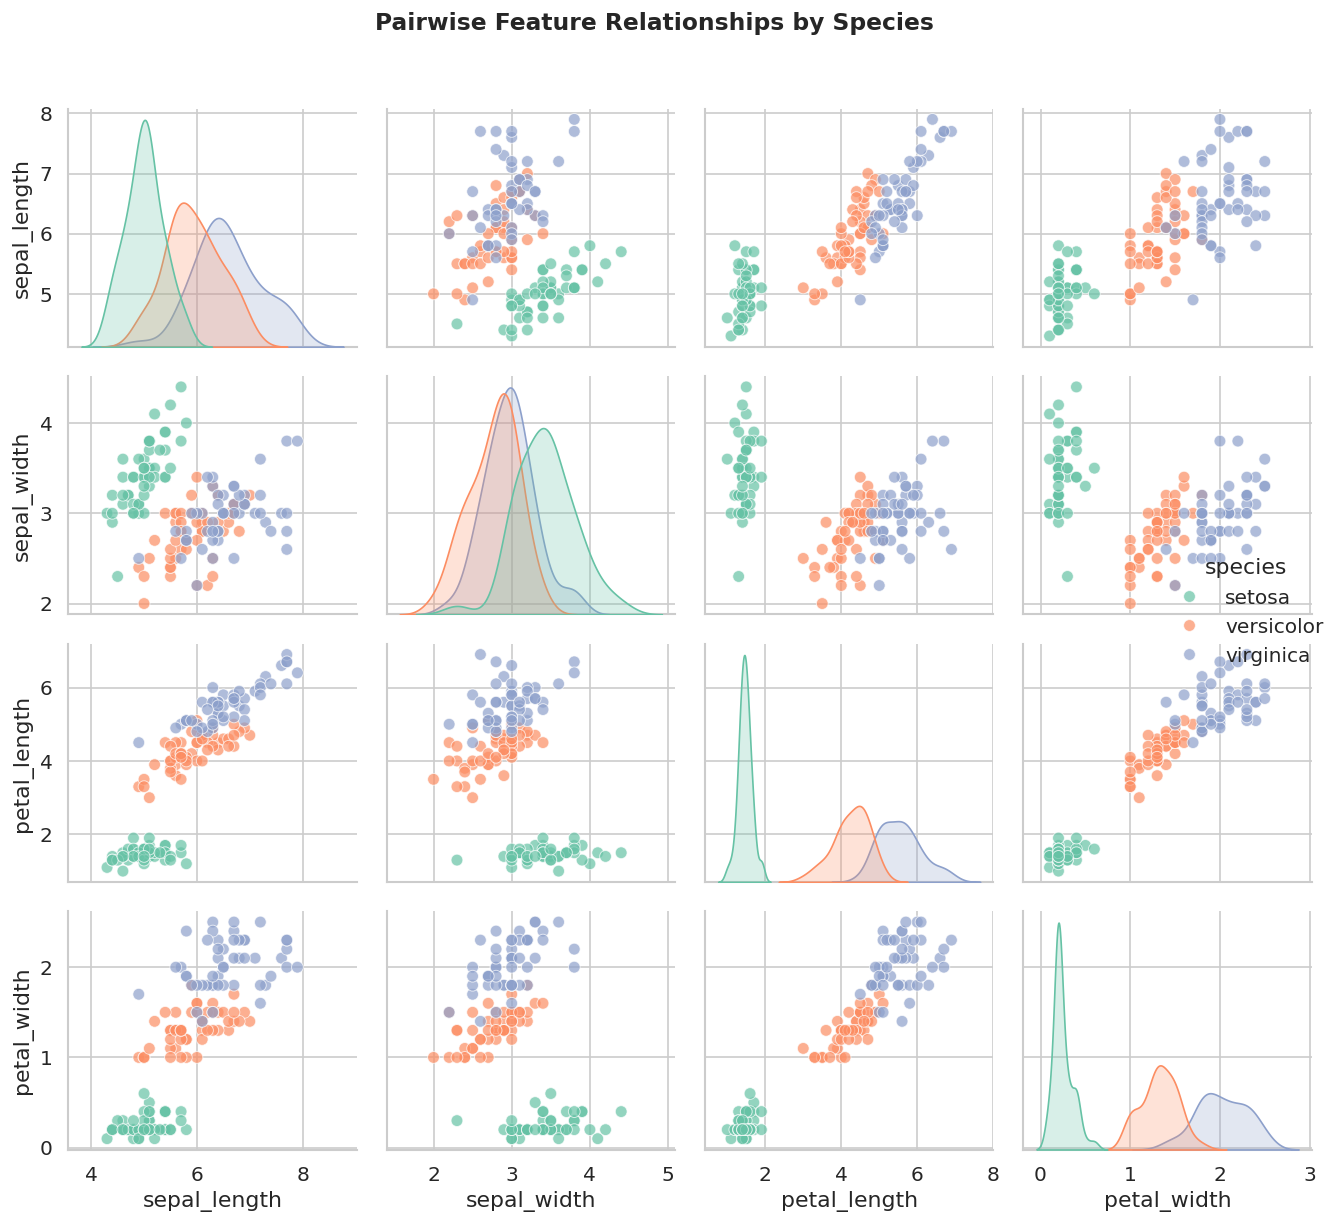


💡 Insight: Petal length & petal width show the clearest separation between species.


In [8]:
# Pairplot: scatter for all feature pairs, colored by species
# Shows which feature combinations best separate the 3 classes

g = sns.pairplot(
    df,
    hue='species',
    diag_kind='kde',          # Kernel density on the diagonal
    plot_kws={'alpha': 0.7, 's': 50},
    palette='Set2'
)
g.fig.suptitle('Pairwise Feature Relationships by Species', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Insight: Petal length & petal width show the clearest separation between species.')

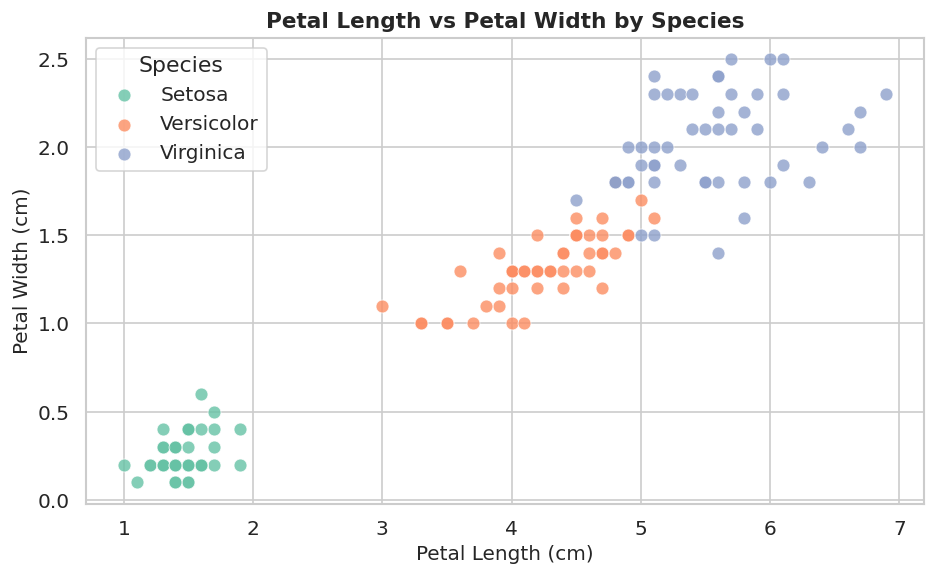

💡 Insight: Setosa is completely separable. Versicolor and Virginica overlap slightly.


In [9]:
# Single scatter: Petal Length vs Petal Width — best separating features
fig, ax = plt.subplots(figsize=(8, 5))

species_colors = {'setosa': '#66C2A5', 'versicolor': '#FC8D62', 'virginica': '#8DA0CB'}

for species, group in df.groupby('species'):
    ax.scatter(
        group['petal_length'],
        group['petal_width'],
        label=species.capitalize(),
        color=species_colors[species],
        s=60, alpha=0.8, edgecolors='white', linewidths=0.5
    )

ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.set_title('Petal Length vs Petal Width by Species', fontsize=13)
ax.legend(title='Species')
plt.tight_layout()
plt.show()

print('💡 Insight: Setosa is completely separable. Versicolor and Virginica overlap slightly.')

### 5.2 — Histograms: Feature Distributions

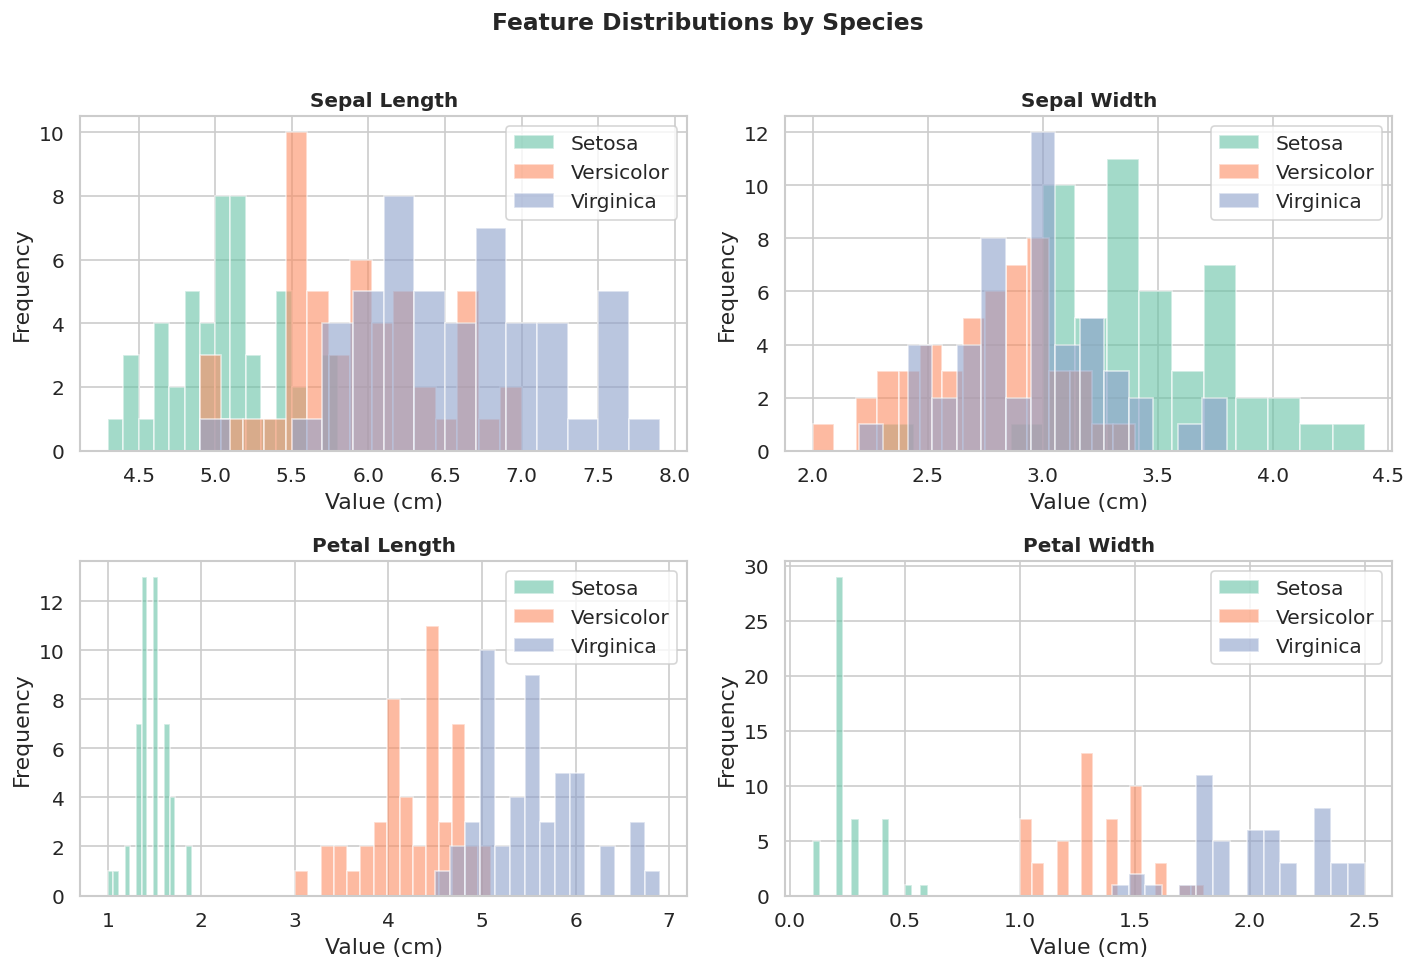

💡 Insight: Petal features are bimodal (Setosa well separated). Sepal width is roughly normal.


In [10]:
# Histogram for each feature, overlaid by species
# Reveals how each feature is distributed and whether it follows a normal curve

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        axes[i].hist(
            subset,
            bins=15,
            alpha=0.6,
            label=species.capitalize(),
            color=list(species_colors.values())[list(df['species'].unique()).index(species)],
            edgecolor='white'
        )
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('Value (cm)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

fig.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Insight: Petal features are bimodal (Setosa well separated). Sepal width is roughly normal.')

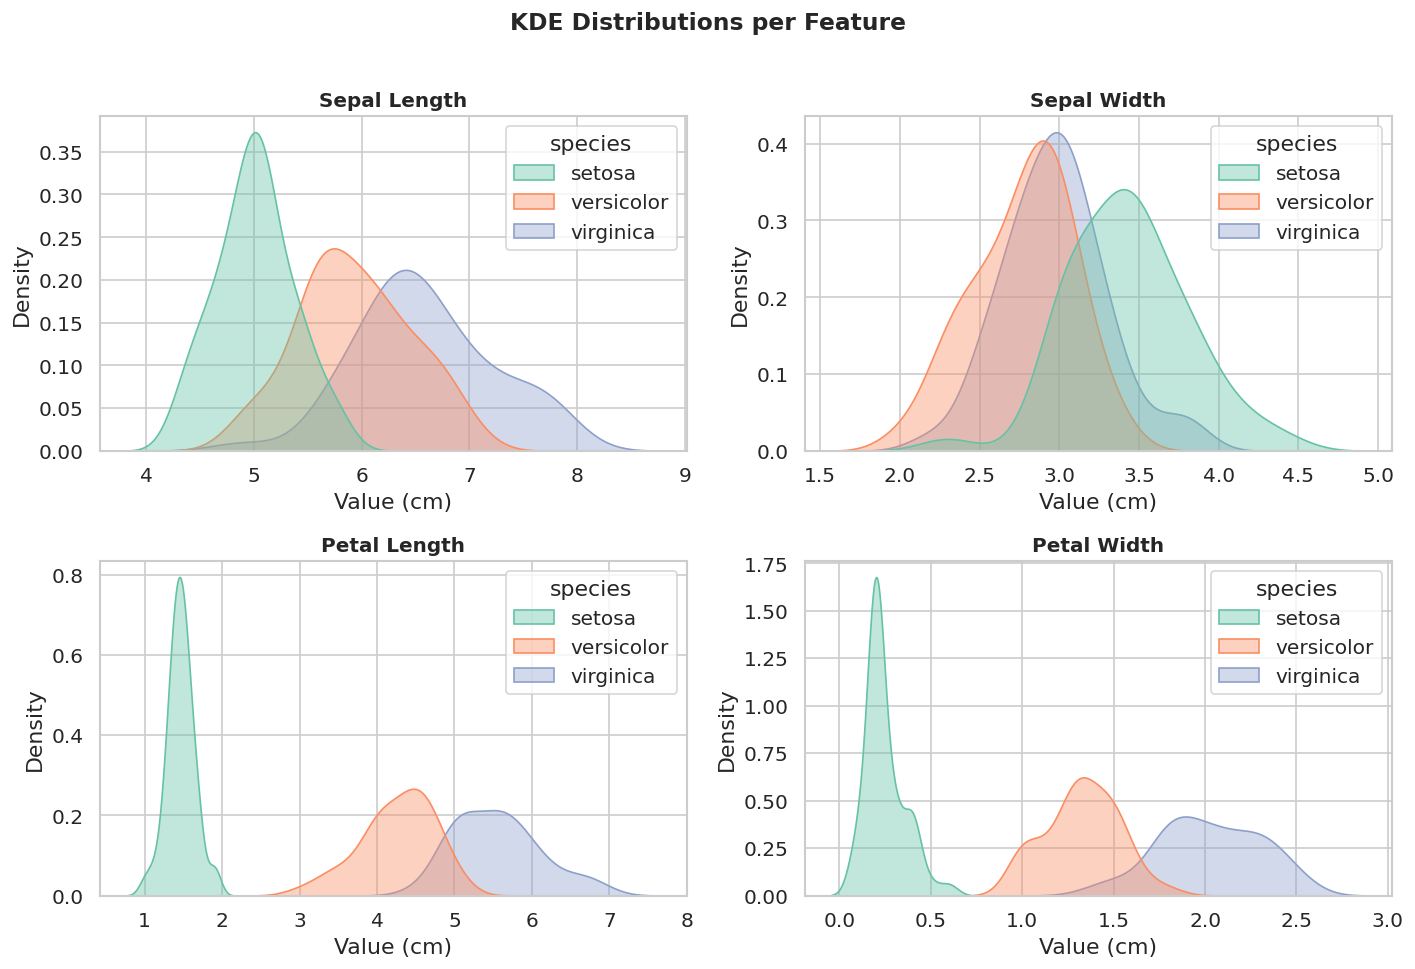

In [11]:
# KDE (Kernel Density Estimate) plots — smooth version of histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(
        data=df, x=feature, hue='species',
        fill=True, alpha=0.4, palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('Value (cm)')

fig.suptitle('KDE Distributions per Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 — Box Plots: Outlier Detection

/tmp/ipykernel_5893/983723699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5893/983723699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5893/983723699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5893/983723699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


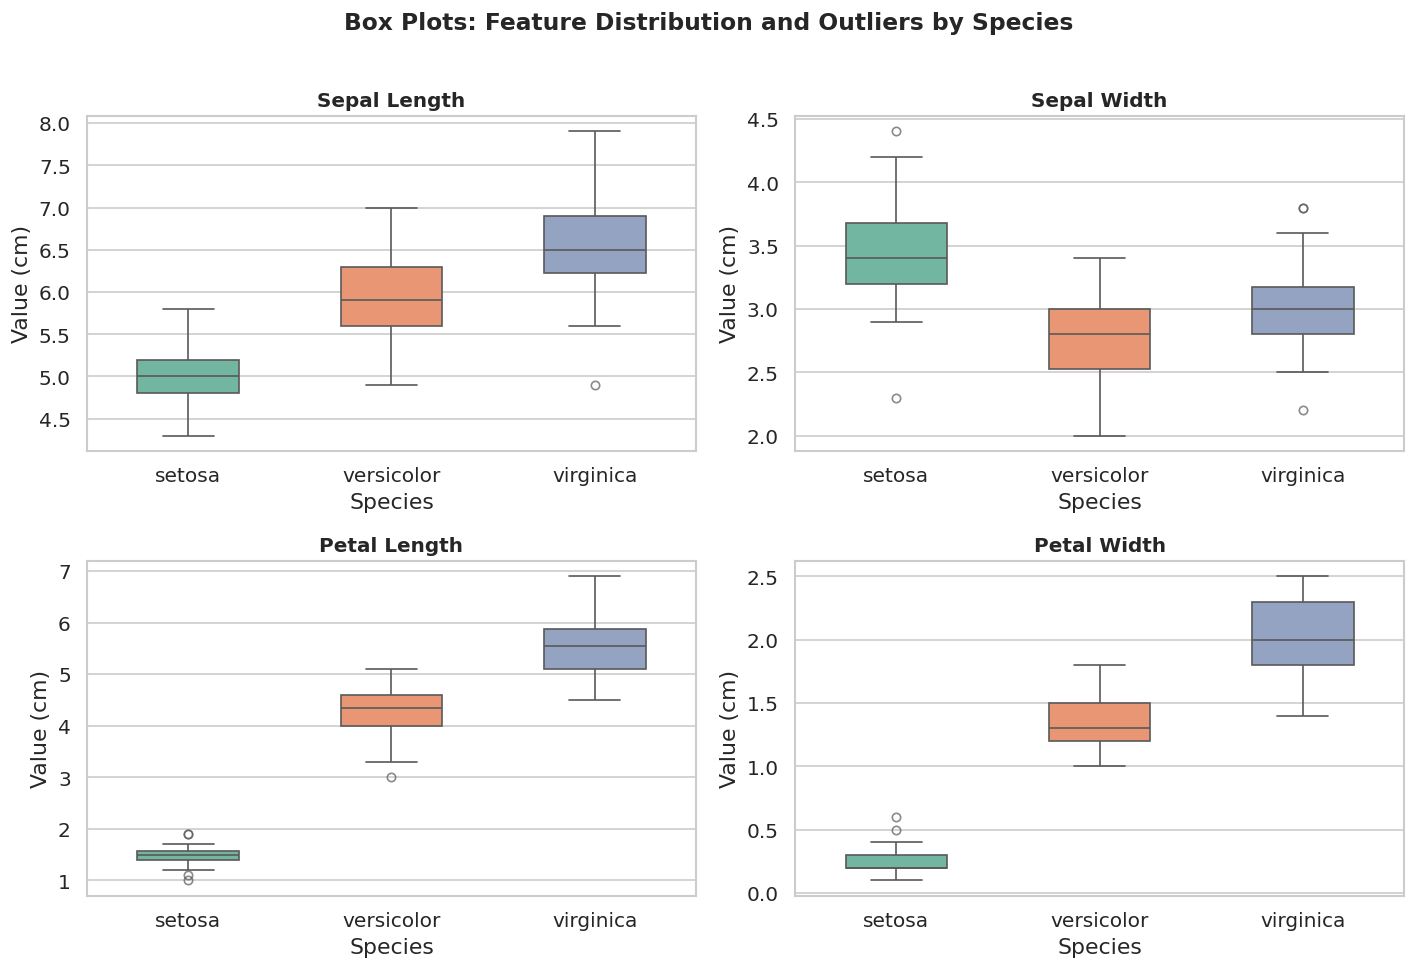

💡 Insight: Sepal width has the most outliers (red dots). Petal features show very tight distributions.


In [12]:
# Box plots per feature, grouped by species
# Box = IQR (25th–75th percentile), whiskers = 1.5×IQR, dots = outliers

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='species',
        y=feature,
        palette='Set2',
        width=0.5,
        flierprops=dict(marker='o', color='red', markersize=5, alpha=0.7),
        ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel('Value (cm)')

fig.suptitle('Box Plots: Feature Distribution and Outliers by Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Insight: Sepal width has the most outliers (red dots). Petal features show very tight distributions.')

/tmp/ipykernel_5893/168885868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_5893/168885868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_5893/168885868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_5893/168885868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


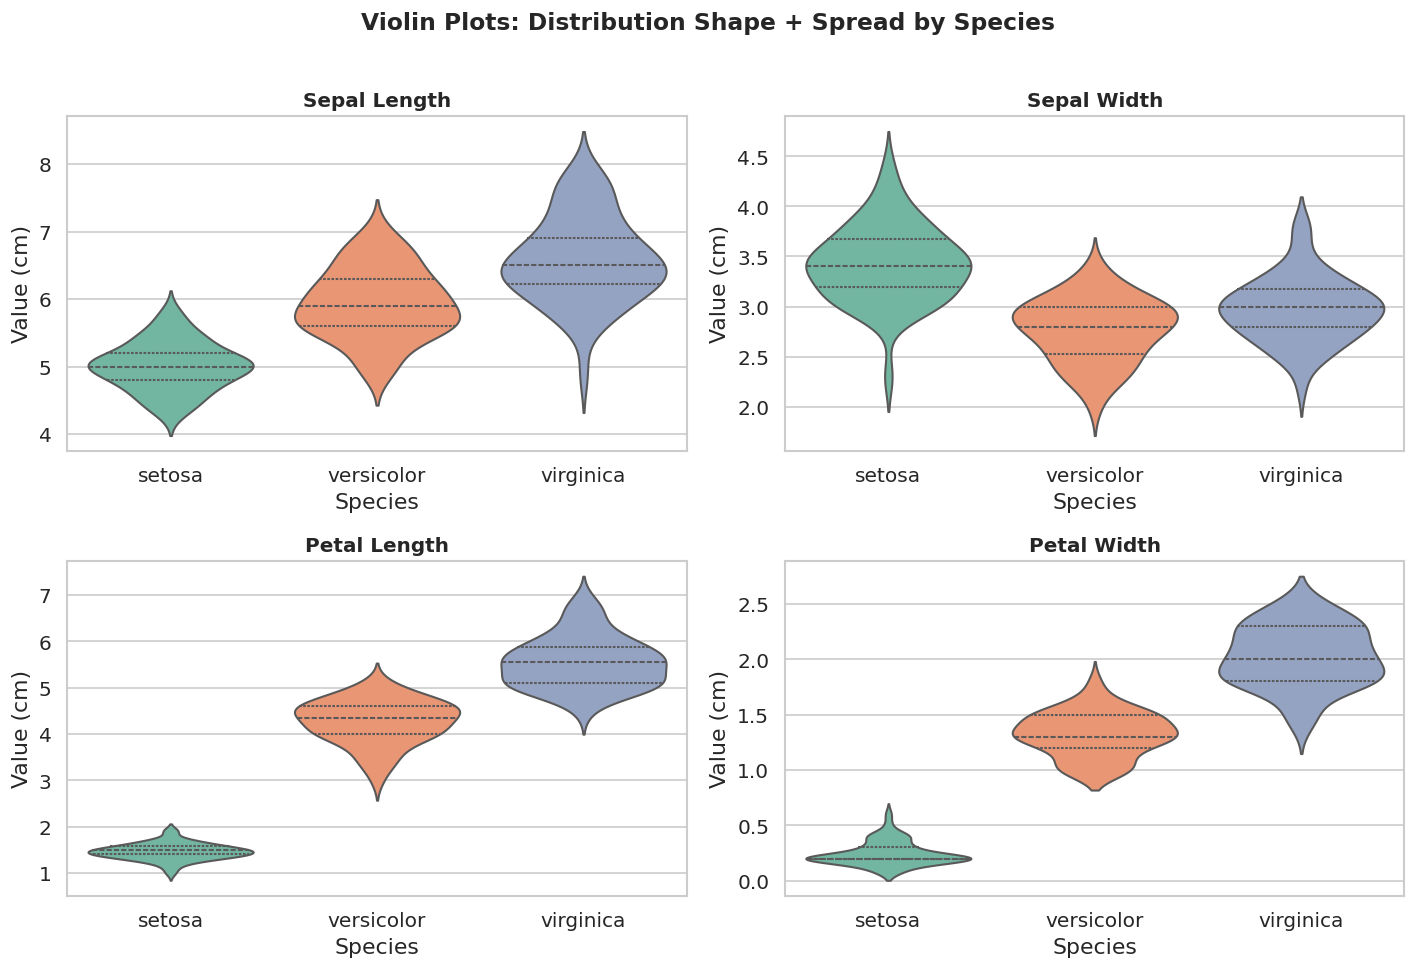

In [13]:
# Violin Plot: combines box plot + KDE — richer view of distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(
        data=df,
        x='species',
        y=feature,
        palette='Set2',
        inner='quartile',   # Shows Q1, median, Q3 lines inside
        ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel('Value (cm)')

fig.suptitle('Violin Plots: Distribution Shape + Spread by Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.4 — Correlation Heatmap

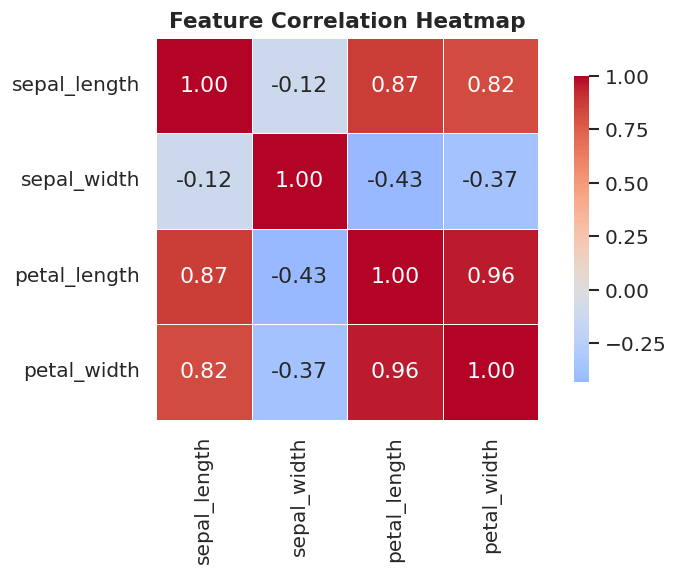

💡 Insight: Petal length & petal width are highly correlated (r=0.96). Sepal width is weakly correlated with others.


In [14]:
# Correlation matrix: how strongly are features related?
# +1 = perfect positive, -1 = perfect negative, 0 = no correlation

corr_matrix = df.drop(columns='species').corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Insight: Petal length & petal width are highly correlated (r=0.96). Sepal width is weakly correlated with others.')

---
## Step 6: Final Insights & Conclusion



In [15]:
# --- Summary Statistics by Species (Final Overview) ---
print('=' * 55)
print('        FINAL DATASET SUMMARY')
print('=' * 55)
print(f'Total Samples   : {len(df)}')
print(f'Features        : {df.shape[1] - 1} numeric + 1 target (species)')
print(f'Classes         : {df["species"].nunique()} (Setosa, Versicolor, Virginica)')
print(f'Missing Values  : {df.isnull().sum().sum()}')
print(f'Class Balance   : {dict(df["species"].value_counts())}')
print('=' * 55)
print('\n✅ Exploration complete! Ready for model training.')

        FINAL DATASET SUMMARY
Total Samples   : 150
Features        : 4 numeric + 1 target (species)
Classes         : 3 (Setosa, Versicolor, Virginica)
Missing Values  : 0
Class Balance   : {'setosa': np.int64(50), 'versicolor': np.int64(50), 'virginica': np.int64(50)}

✅ Exploration complete! Ready for model training.
